# Libraries

In [1]:
# Correlation
import pandas as pd
import numpy as np
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

import shap

from scipy.stats import chi2_contingency
from scipy import stats
from sklearn.linear_model import LogisticRegression
from scipy.stats import shapiro
from scipy.stats import normaltest
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

C:\Users\Eugenia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dummies Data
- Collinearity check only on train data that are going to be used.
- Test data are 'unseen' --> No feature selection methods like this.

In [2]:
df1 = pd.read_pickle(r".\df_dummies_unmerged\df1_dummies_unmerged.pkl")
df2 = pd.read_pickle(r".\df_dummies_unmerged\df2_dummies_unmerged.pkl")
df3 = pd.read_pickle(r".\df_dummies_unmerged\df3_dummies_unmerged.pkl")
df4 = pd.read_pickle(r".\df_dummies_unmerged\df4_dummies_unmerged.pkl")

df1_merge = pd.read_pickle(r".\df_dummies\df1_dummies.pkl")
df2_merge = pd.read_pickle(r".\df_dummies\df2_dummies.pkl")
df3_merge = pd.read_pickle(r".\df_dummies\df3_dummies.pkl")
df4_merge = pd.read_pickle(r".\df_dummies\df4_dummies.pkl")

## Train test Split

In [3]:
def fun_train_test(dfi):

    X = dfi.drop("Study_Status_Bin", axis = 1)
    y = dfi["Study_Status_Bin"]

    X_train_tts, X_test_tts, y_train_tts, y_test_tts = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

    # Resample needed only for Sparsity in Train set. here All train set can be used. 
    # res = RandomUnderSampler(sampling_strategy = 'auto', random_state = 42)
    # X_train_res, y_train_res = res.fit_resample(X_train_tts, y_train_tts) 
    
    X_train_tts = pd.DataFrame(X_train_tts)

    return X_train_tts, y_train_tts

In [4]:
X_train1, y_train1 = fun_train_test(df1)
X_train2, y_train2 = fun_train_test(df2)
X_train3, y_train3 = fun_train_test(df3)
X_train4, y_train4 = fun_train_test(df4)

X_train1_merge, y_train1_merge = fun_train_test(df1_merge)
X_train2_merge, y_train2_merge = fun_train_test(df2_merge)
X_train3_merge, y_train3_merge = fun_train_test(df3_merge)
X_train4_merge, y_train4_merge = fun_train_test(df4_merge)

# Functions

## Normal test

In [30]:
def fun_norm(dfi, i):
    cont_cols = [col for col in dfi.columns if '_Counts' in col or '_Log' in col]
    norm_all = []
    for col in cont_cols:
        stat, p = normaltest(dfi[col].dropna())  # dropna για ασφάλεια
        norm_all.append({"Variable": col, f"df{i}-Stat": stat, f"df{i}-p_value": p})

    norm = pd.DataFrame(norm_all)
    norm['Approx.Normal'] = np.where(norm[f"df{i}-p_value"] < 0.05, '-', 'Approx.Normal')
    
    return norm


## Continuous Heatmap

In [31]:
def fun_cont_heat(dfi, i, figsize, threshold, fontsize, title, show, rotation):
    cont_cols = [col for col in dfi.columns if '_Counts' in col or '_Log' in col]

    corr = dfi[cont_cols].corr(method = "spearman")
    mask = corr < threshold

    plt.figure(figsize = figsize)
    sns.heatmap(corr, cmap = "coolwarm", cbar = True,
                annot = True, vmin=0, vmax=1, mask=mask, fmt = ".1f",
                xticklabels = corr.columns, yticklabels = corr.columns)
    plt.title(f'df{i} - ' + title, fontsize = 10, fontweight = 'bold', pad = 20)
    plt.xticks(fontsize = fontsize, rotation = rotation)
    plt.yticks(fontsize = fontsize)
    if show:
        plt.show()
    else:
        plt.close()
    return corr

## Categ Heatmap

In [32]:
def fun_cramers_v(x, y):       
    chi2 = chi2_contingency(pd.crosstab(x, y))[0]
    n = pd.crosstab(x, y).sum().sum()
    r, k = pd.crosstab(x, y).shape
    if min(r, k) <= 1 or n == 0:
        return np.nan
    corr = np.sqrt(chi2 / (n * (min(r, k) - 1))) if n > 0 else np.nan # CramerV (Phi) Effect Size of Chi-Square
    return corr

############################################################################################################
def fun_matric(categ_cols, dfi):
    dfi_cat = dfi[categ_cols]
    n = len(categ_cols)
    corr_categ = pd.DataFrame(np.zeros((n, n)), index = categ_cols, columns = categ_cols) 

    for i in range(n):
        for j in range(i, n):
            if i == j:
                corr = 1.0
            else:
                corr = fun_cramers_v(dfi_cat.iloc[:, i], dfi_cat.iloc[:, j])  

            corr_categ.iloc[i, j] = corr
            corr_categ.iloc[j, i] = corr           
    return corr_categ.round(4)

############################################################################################################
def fun_cramer_heat(dfi, i, categ_cols, figsize, annot, threshold, fontsize, title, show, rotation):
    corr_categ = fun_matric(categ_cols, dfi)

    mask = corr_categ < threshold

    plt.figure(figsize = figsize, dpi = 100)
    sns.heatmap(corr_categ,
        annot=annot, fmt = ".1f", vmin = 0, vmax=1, mask=mask,
        cmap="coolwarm",
        cbar_kws = {"label": "Cramér's V Association"},
        xticklabels=corr_categ.columns,
        yticklabels=corr_categ.index)
    
    plt.title(f'df{i} - ' + title, fontsize = 10, fontweight = 'bold', pad = 20)
    plt.xticks(rotation = rotation, fontsize = fontsize)
    plt.yticks(fontsize = fontsize)
    if show:
        plt.show()
    else:
        plt.close()
    return corr_categ

## Categ x Cont Heatmap

In [33]:
def fun_eta(categ_cols, cont_cols):
    categories = pd.Categorical(categ_cols)
    cat_levels = categories.categories

    y_mean = np.mean(cont_cols)
    ss_between = 0
    ss_total = np.sum((cont_cols - y_mean) ** 2)

    for cat in cat_levels:
        vals = cont_cols[categ_cols == cat]
        if len(vals) > 0:
            ss_between += len(vals) * (np.mean(vals) - y_mean) ** 2

    eta = np.sqrt(ss_between / ss_total) if ss_total != 0 else 0
    return eta

############################################################################################################

def fun_anova(dfi, i, categ_cols, cont_cols, annot, figsize, threshold, fontsize, title, show, rotation):
    corr_matrix = pd.DataFrame(index = cont_cols, columns = categ_cols, dtype=float)

    for cat in categ_cols:
        for cont in cont_cols:
            corr_matrix.loc[cont, cat] = fun_eta(dfi[cat], dfi[cont])

    mask = corr_matrix < threshold

    plt.figure(figsize=figsize, dpi=100)
    sns.heatmap(
        corr_matrix,
        annot = annot,
        fmt=".1f",
        vmin=0,
        vmax=1,
        mask=mask,
        cmap="coolwarm",
        cbar_kws={"label": "Correlation Ratio (η)"},
        xticklabels=corr_matrix.columns,
        yticklabels=corr_matrix.index
    )

    plt.xticks(fontsize=fontsize, rotation = rotation)
    plt.yticks(fontsize=fontsize)
    plt.title(f'df{i} - ' + title, fontsize = 10, fontweight = 'bold', pad=20)

    if show:
        plt.show()
    else:
        plt.close()

    return corr_matrix


## Model Compare

In [34]:
def fun_aic(X, y, i, cont, display_log=False):
# Model 
    if cont:
        X = sm.add_constant(X) # continuous features always add constant else LLR = nan. Nothing to compare the coeff.
        model = sm.Logit(y, X)
    else:
        X = sm.add_constant(X)
        X = X.drop(X.columns[1], axis=1)  # Drop first column after adding constant to avoid multicollinearity
        model = sm.Logit(y, X) 
    
    results = model.fit(method = 'lbfgs', maxiter = 1000)

    if display_log == True:
        print(results.summary())
# AIC
    aic = round(results.aic, 0)  # AIC test in case needed for comparison
    return aic

# Merged Data Check
- Collinearity check 

## Funder

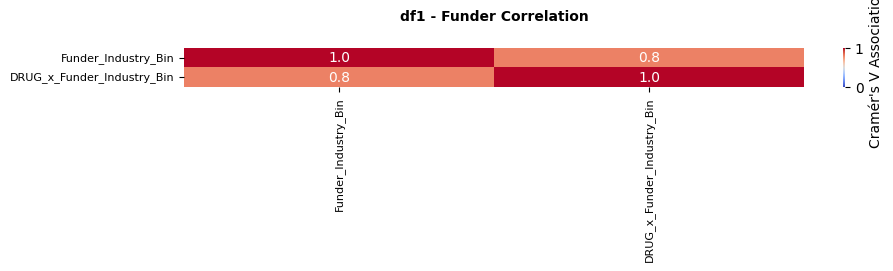

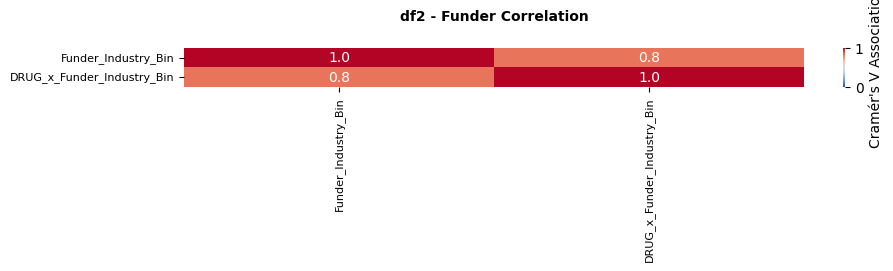

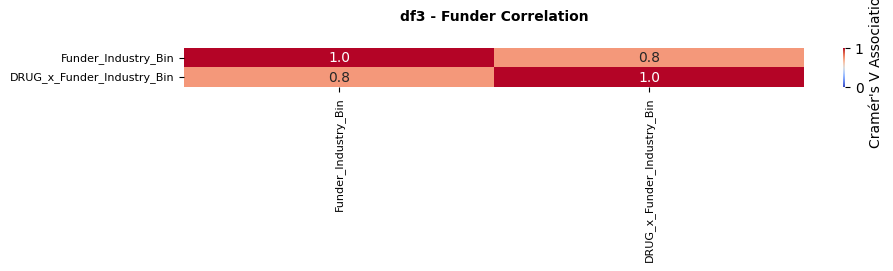

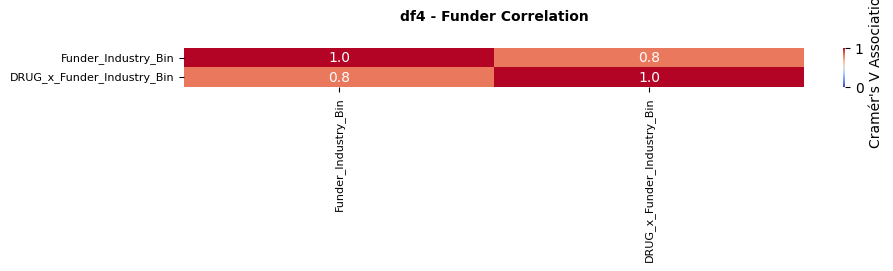

In [ ]:
figsize = (10, 0.5)
threshold = 0.7
fontsize = 8
title = f'Funder Correlation'
show = True
rotation = 0

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):
    fun_cramer_heat(X_traini_merge, i, [col for col in X_traini_merge.columns if 'Funder_Industry_Bin' in col], 
                    figsize = figsize, annot = True, threshold = threshold, fontsize = fontsize, title = title, show = show, 
                    rotation = rotation)


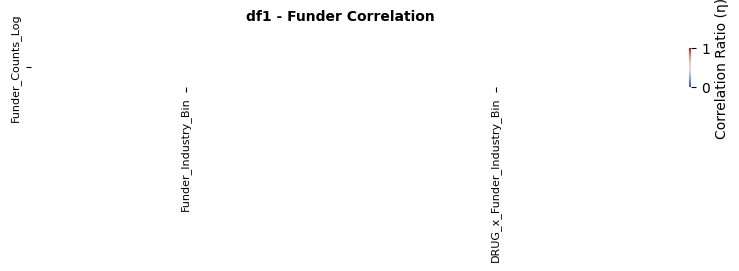

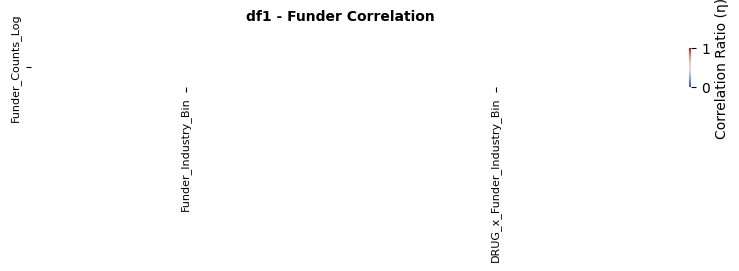

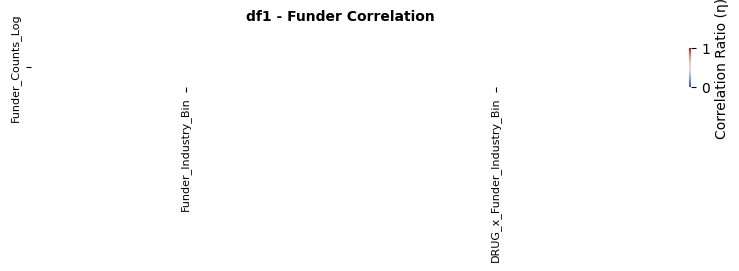

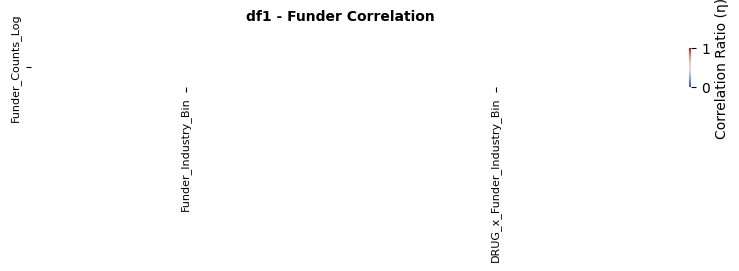

In [ ]:
figsize = (10, 0.5)
threshold = 0.7
fontsize = 8
title = f'Funder Correlation'
show = True
rotation = 0

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):

    fun_anova(X_traini_merge, 1, 
    categ_cols = [col for col in X_traini_merge.columns if 'Funder_Industry_Bin' in col], 
    cont_cols = ['Funder_Counts_Log'], annot = True, figsize = figsize, 
    threshold = threshold, fontsize = fontsize, title=title, show = show, rotation = rotation)    

## Enrollment_x_Cond ~ Enrollment


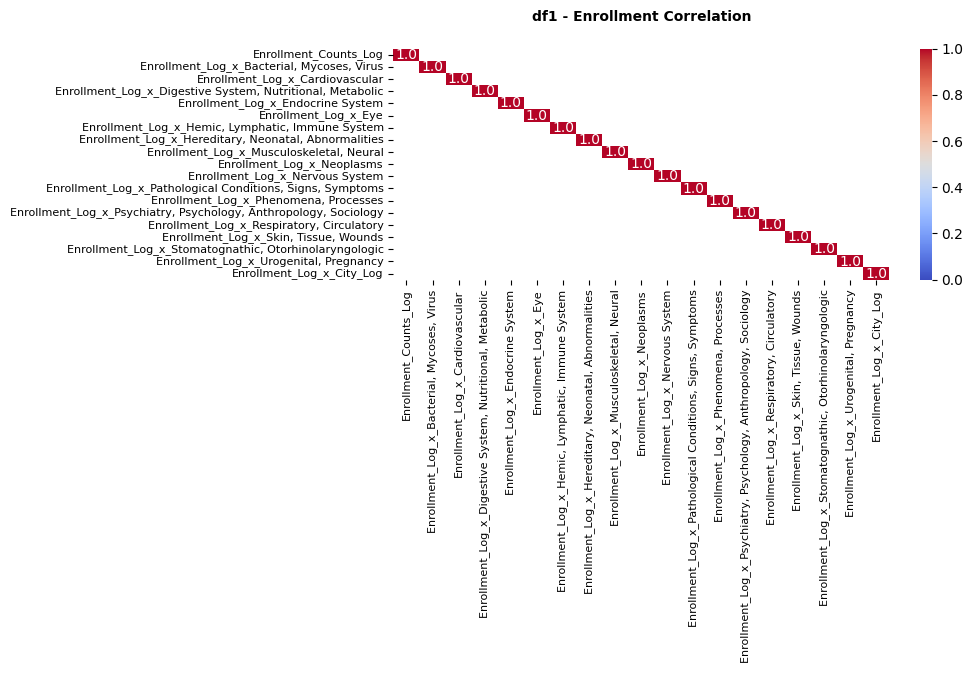

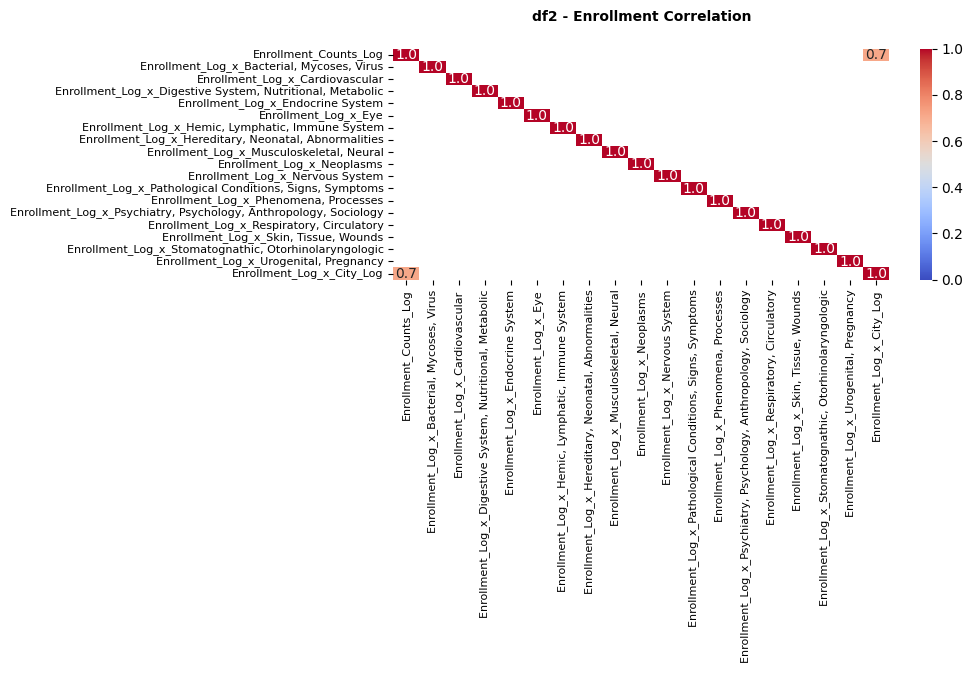

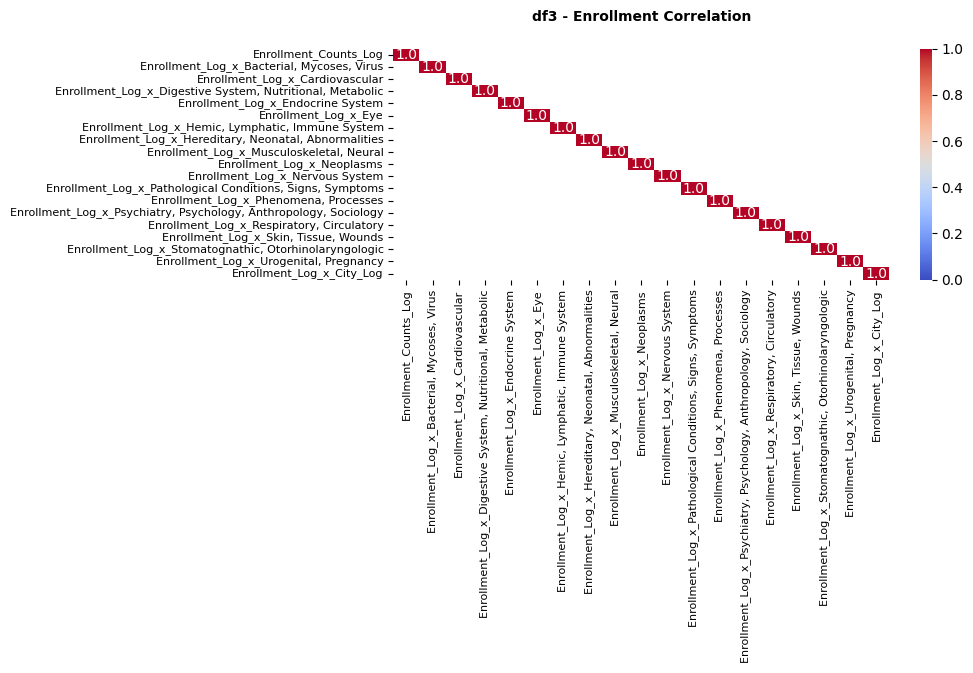

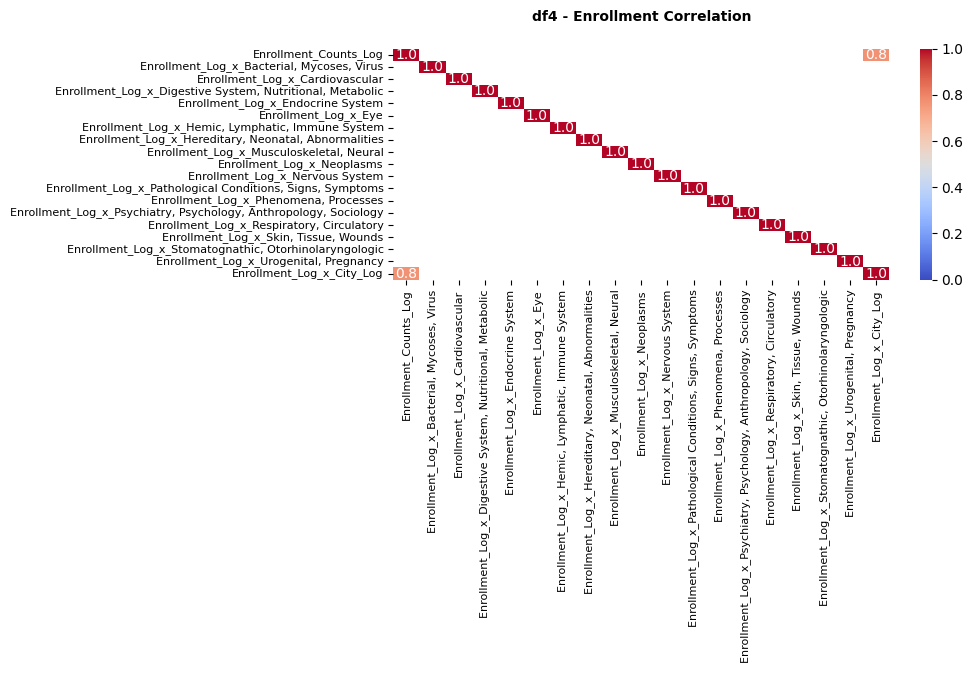

In [39]:
figsize = (8, 3)
threshold = 0.7
fontsize = 8
title = f'Enrollment Correlation'
show = True
rotation = 90

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):
    fun_cont_heat(X_traini_merge[[col for col in X_traini_merge.columns if 'Enrollment' in col]], i, 
                  figsize, threshold, fontsize, title, show, rotation = rotation)

## Enrollment_x_Cond ~ Conditions
- Cont ~ categ

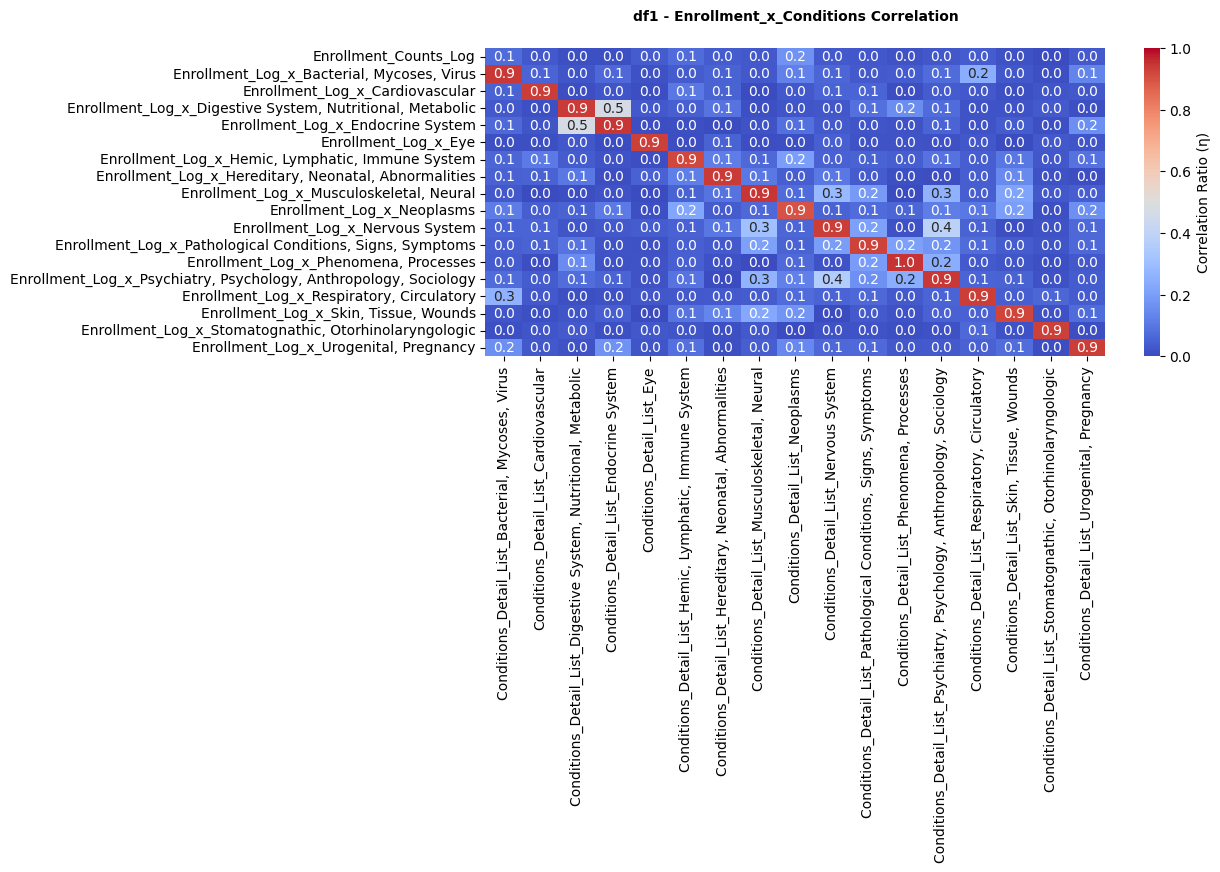

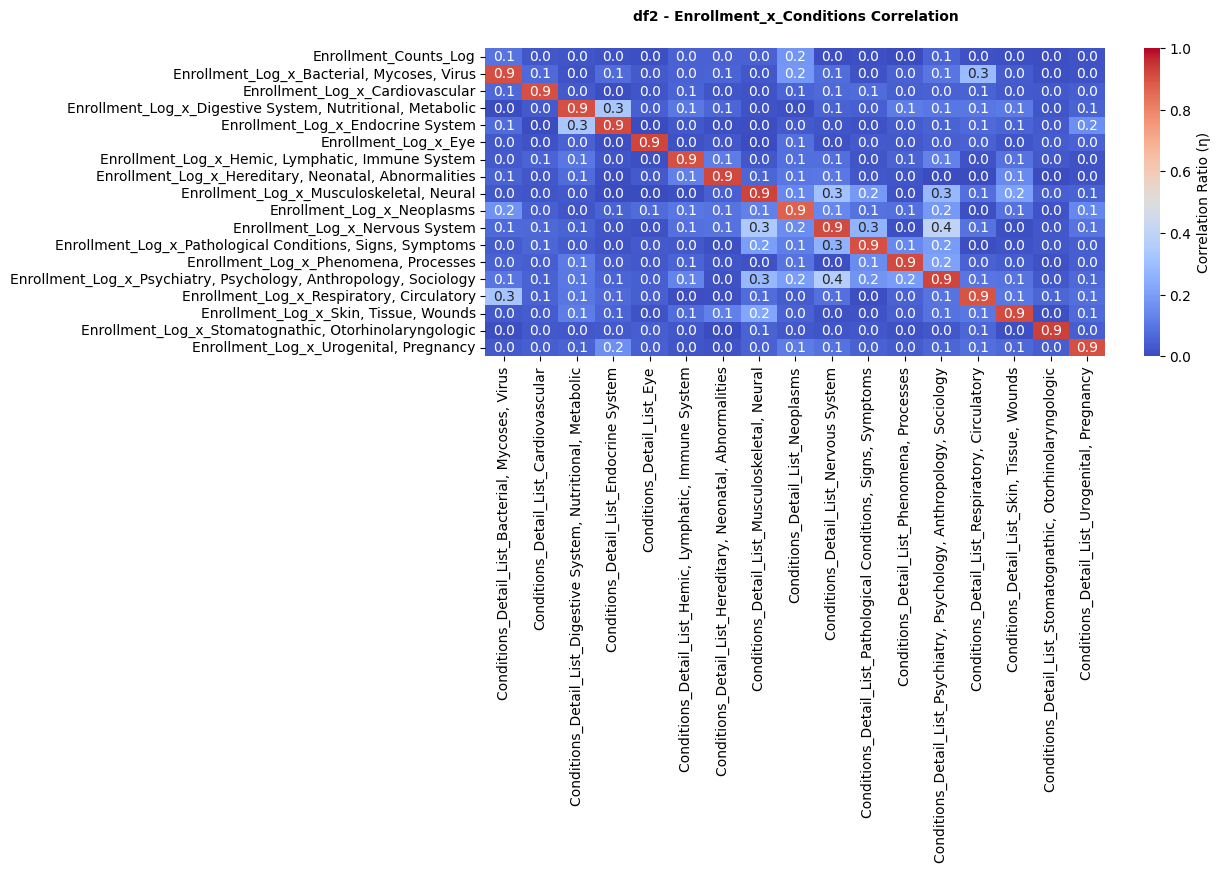

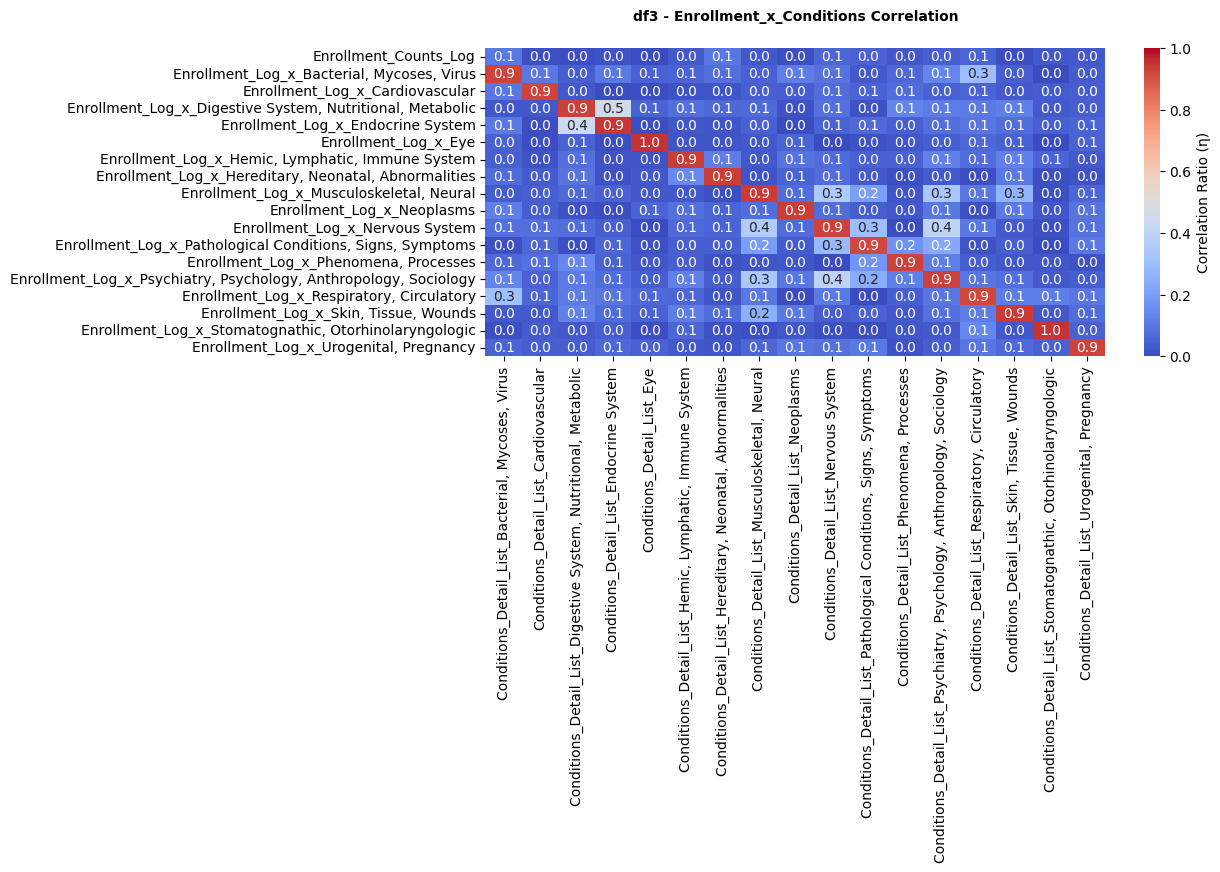

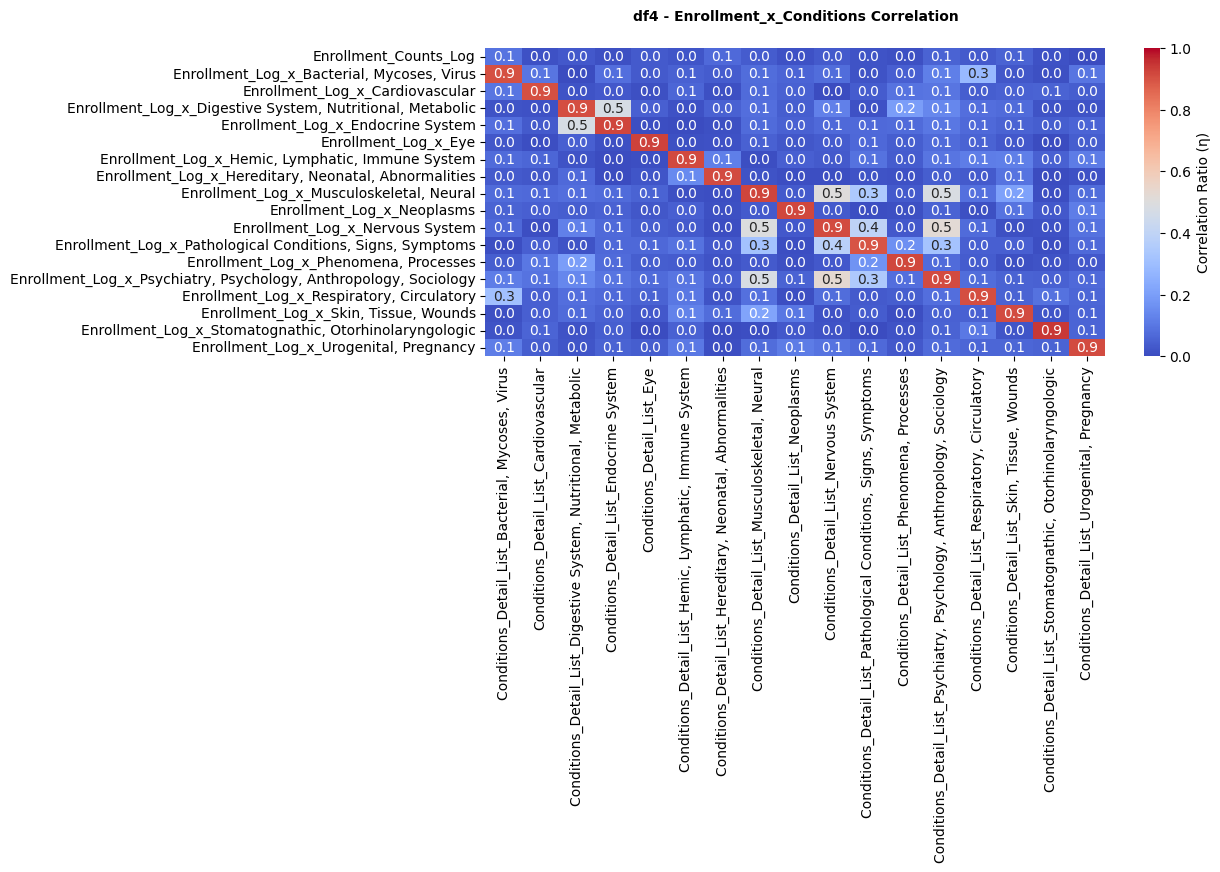

In [ ]:
figsize = (10, 4)
threshold = 0.0
fontsize = 10
title = f'Enrollment_x_Conditions Correlation'
show = True
rotation = 90

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):
        fun_anova(X_traini_merge, i, 
        categ_cols = [col for col in X_traini_merge.columns if 'Conditions_Detail' in col], 
        cont_cols = [col for col in X_traini_merge.columns if 'Enrollment' in col and 'Enrollment_Log_x_City_Log' not in col], 
        annot = True, figsize = figsize, threshold = threshold, fontsize = fontsize, title = title, show = show, 
        rotation = rotation)
        

## Enrollment_x_City ~ City
- Cont vs Cont

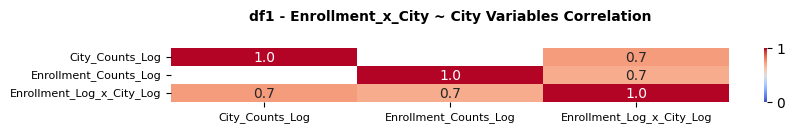

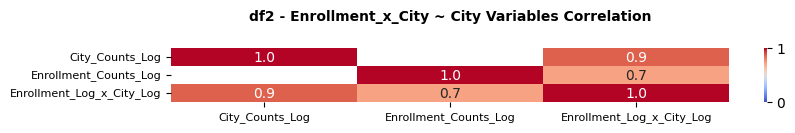

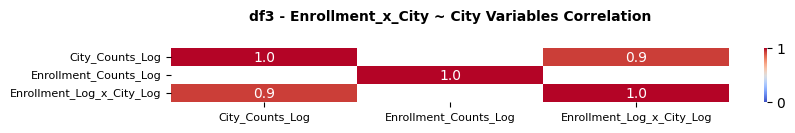

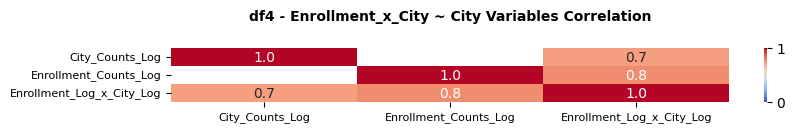

In [ ]:
figsize = (9, 0.7)
threshold = 0.7
fontsize = 8
title = f'Enrollment_x_City ~ City Variables Correlation'
show = True
rotation = 0

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):
    fun_cont_heat(X_traini_merge[[col for col in X_traini_merge.columns if 'City' in col or 'Enrollment_Counts_Log' in col]], i, 
                    figsize, threshold, fontsize, title, show, rotation = rotation)


## Enrollment_City ~ Global

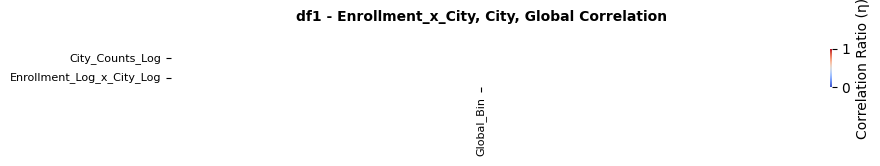

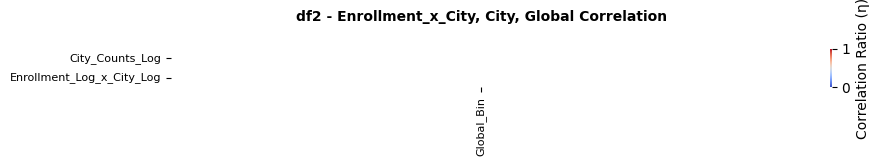

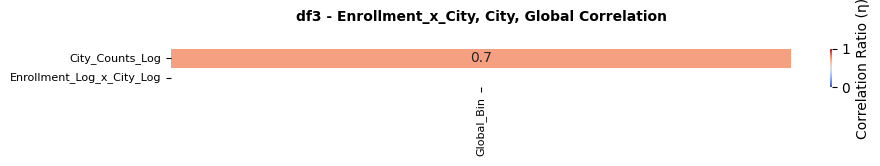

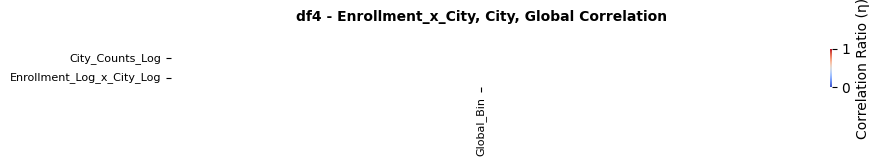

In [ ]:
figsize = (10, 0.5)
threshold = 0.7
fontsize = 8
title = f'Enrollment_x_City, City, Global Correlation'
show = True
rotation = 0

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):

    fun_anova(X_traini_merge, i, 
        categ_cols = [col for col in X_traini_merge.columns if 'Global_Bin' in col], 
        cont_cols = [col for col in X_traini_merge.columns if 'Enrollment_Log_x_City_Log' in col or 'City_Counts' in col \
                     or 'Enrollment_Counts' in col and 'Enrollment_Counts_Log' not in col], 
        annot = True, figsize = figsize, threshold = threshold, fontsize = fontsize, title = title, show = show, 
        rotation = rotation)  

## Adverse

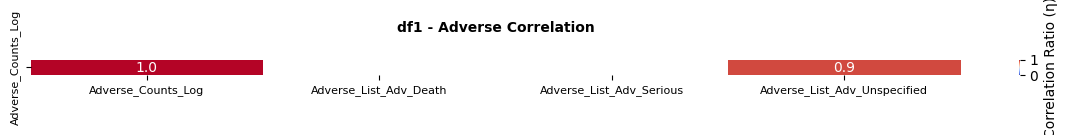

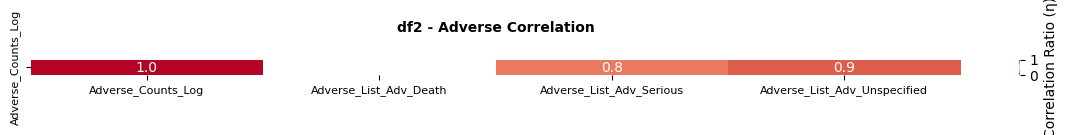

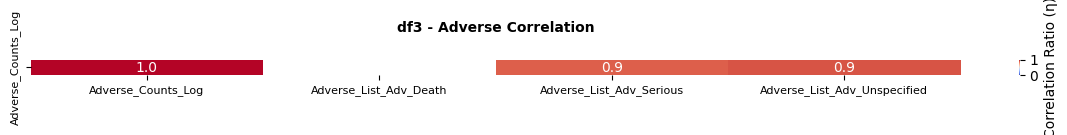

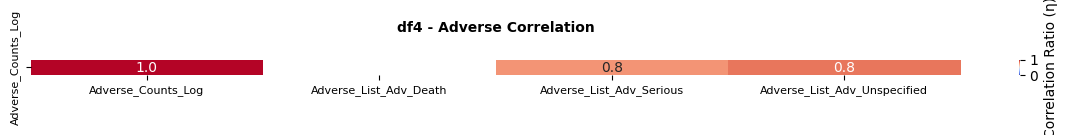

In [41]:
figsize = (15, 0.2)
threshold = 0.7
fontsize = 8
title = f'Adverse Correlation'
show = True
rotation = 0

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):

    fun_anova(X_traini_merge, i, 
        categ_cols = [col for col in X_traini_merge.columns if 'Adverse' in col], 
        cont_cols = [col for col in X_traini_merge.columns if 'Adverse' in col and '_Counts' in col], 
        annot = True, figsize = figsize, threshold = threshold, fontsize = fontsize, title = title, show = show, 
        rotation = rotation)  

## Continuous all 


In [ ]:
figsize = (8, 0.7)
threshold = 0.7
fontsize = 8
title = f'Continuous Variables Correlation'
show = True
rotation = 90

for i, X_traini_merge in zip([1,2,3,4], [X_train1_merge, X_train2_merge, X_train3_merge, X_train4_merge]):
    fun_cont_heat(X_traini_merge[[col for col in X_traini_merge.columns if '_Log' in col and ('City' not in col \
                                  and 'Enrollment' not in col)]], i, 
                  figsize, threshold, fontsize, title, show, rotation = rotation)



# Unmerged Data Check
- Feature Selection

## Continues x Continues

### Normality test

In [69]:
norm1 = fun_norm(X_train1, 1)
norm2 = fun_norm(X_train2, 2)
norm3 = fun_norm(X_train3, 3)
norm4 = fun_norm(X_train4, 4)

display(norm1, norm2, norm3, norm4)

,Variable,df1-Stat,df1-p_value,Approx.Normal
0,Enrollment_Counts,31256.625945,0.0,-
1,Funder_Counts,14958.855486,0.0,-
2,Funder_Counts_Log,6887.033103,0.0,-
3,Intervention_Type_Counts,16085.769407,0.0,-
4,Intervention_Route_Counts,8910.525578,0.0,-
5,Adverse_Counts,52856.033082,0.0,-
6,Adverse_Counts_Log,8551.290728,0.0,-
7,Adverse_System_Counts,10697.121311,0.0,-
8,Adverse_System_Counts_Log,7063.476343,0.0,-
9,Arm_Counts,13118.098889,0.0,-


,Variable,df2-Stat,df2-p_value,Approx.Normal
0,Enrollment_Counts,71891.466095,0.000000e+00,-
1,Funder_Counts,22569.343852,0.000000e+00,-
2,Funder_Counts_Log,7226.010313,0.000000e+00,-
3,Intervention_Type_Counts,13029.138146,0.000000e+00,-
4,Intervention_Route_Counts,7122.099542,0.000000e+00,-
5,Adverse_Counts,31170.584573,0.000000e+00,-
6,Adverse_Counts_Log,3095.349223,0.000000e+00,-
7,Adverse_System_Counts,2361.757073,0.000000e+00,-
8,Adverse_System_Counts_Log,105321.332759,0.000000e+00,-
9,Arm_Counts,13150.760003,0.000000e+00,-


,Variable,df3-Stat,df3-p_value,Approx.Normal
0,Enrollment_Counts,28695.948896,0.000000e+00,-
1,Funder_Counts,15507.967543,0.000000e+00,-
2,Funder_Counts_Log,7069.013373,0.000000e+00,-
3,Intervention_Type_Counts,8986.487202,0.000000e+00,-
4,Intervention_Route_Counts,5386.335562,0.000000e+00,-
5,Adverse_Counts,19711.793318,0.000000e+00,-
6,Adverse_Counts_Log,17691.599623,0.000000e+00,-
7,Adverse_System_Counts,1893.924389,0.000000e+00,-
8,Adverse_System_Counts_Log,50165.102677,0.000000e+00,-
9,Arm_Counts,10275.408638,0.000000e+00,-


,Variable,df4-Stat,df4-p_value,Approx.Normal
0,Enrollment_Counts,35855.020660,0.000000e+00,-
1,Funder_Counts,20374.563314,0.000000e+00,-
2,Funder_Counts_Log,5868.927274,0.000000e+00,-
3,Intervention_Type_Counts,7662.966551,0.000000e+00,-
4,Intervention_Route_Counts,2857.254693,0.000000e+00,-
5,Adverse_Counts,40795.359991,0.000000e+00,-
6,Adverse_Counts_Log,4559.326021,0.000000e+00,-
7,Adverse_System_Counts,6901.084927,0.000000e+00,-
8,Adverse_System_Counts_Log,3444.603595,0.000000e+00,-
9,Arm_Counts,12830.087922,0.000000e+00,-


### All Continuous

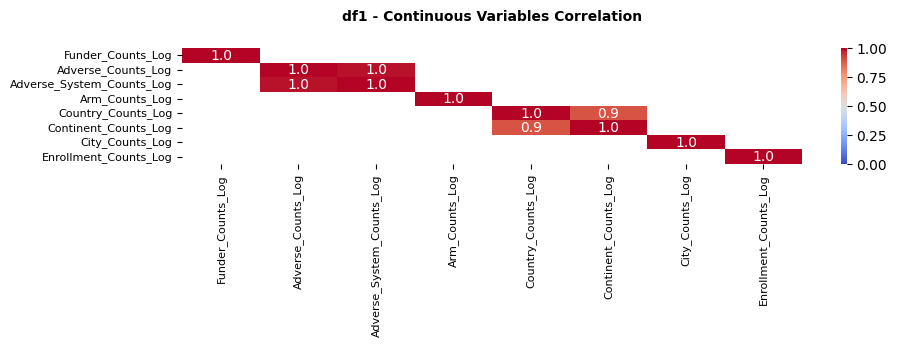

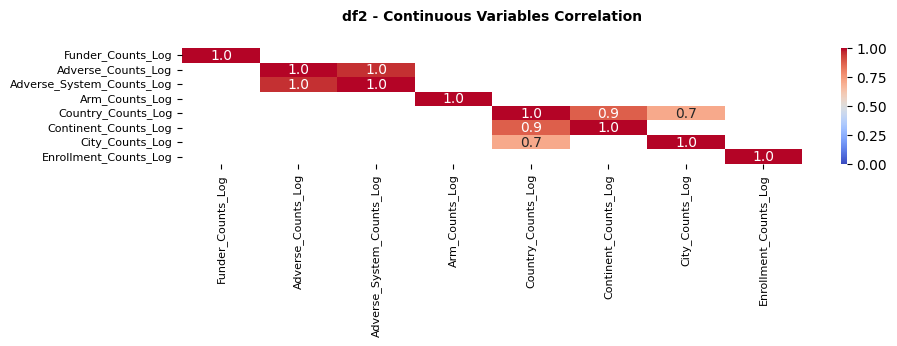

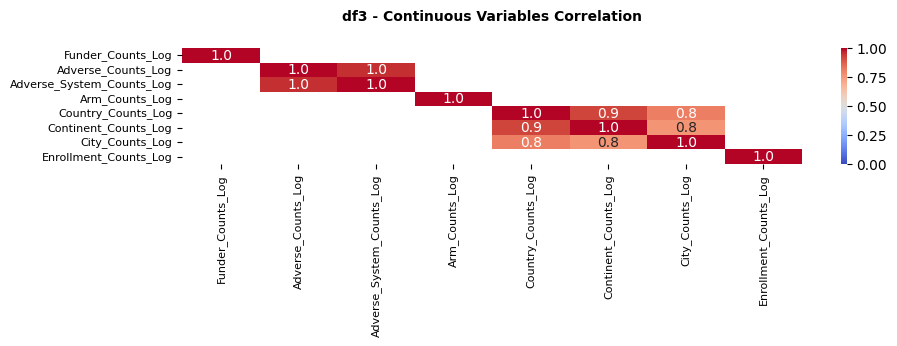

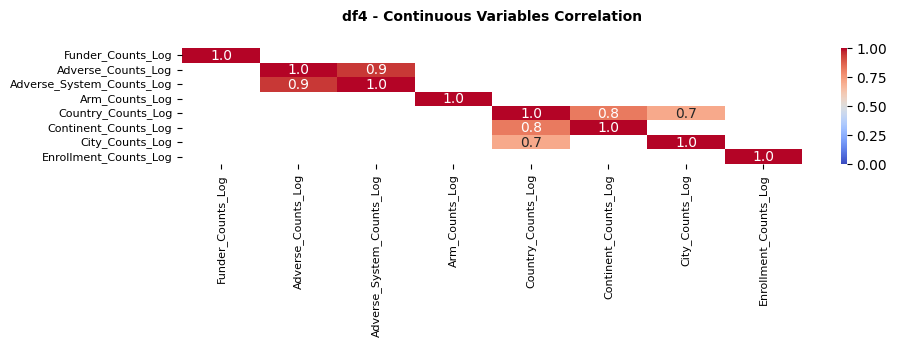

In [ ]:
figsize = (10, 1.5)
threshold = 0.7
fontsize = 8
title = f'Continuous Variables Correlation'
show = True
rotation = 90

cont_corr1 = fun_cont_heat(X_train1[[col for col in X_train1.columns if '_Log' in col]], 1, figsize, threshold, fontsize, title, show, 
                           rotation = rotation)
cont_corr2 = fun_cont_heat(X_train2[[col for col in X_train1.columns if '_Log' in col]], 2, figsize, threshold, fontsize, title, show, 
                           rotation = rotation)
cont_corr3 = fun_cont_heat(X_train3[[col for col in X_train1.columns if '_Log' in col]], 3, figsize, threshold, fontsize, title, show, 
                           rotation = rotation)
cont_corr4 = fun_cont_heat(X_train4[[col for col in X_train1.columns if '_Log' in col]], 4, figsize, threshold, fontsize, title, show, 
                           rotation = rotation)

# All _Counts col will be dropped as decided in Thesis_Visual_Train

## Categ x Categ

In [ ]:
# 4 mins --> All dfs give same output regarding correlation
figsize = (30, 30)
threshold = 0.7
fontsize = 10
title = f'categorical variables Correlation'
show = False
rotation = 90

categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if '_Bin' in col or '_List' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)
# categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if '_List' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)
# categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if '_List' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)
# categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if '_List' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)

# categ_cols = [col for col in dfi.columns if '_Categ' in col or '_Bin' in col or '_List' in col]


### Conditions

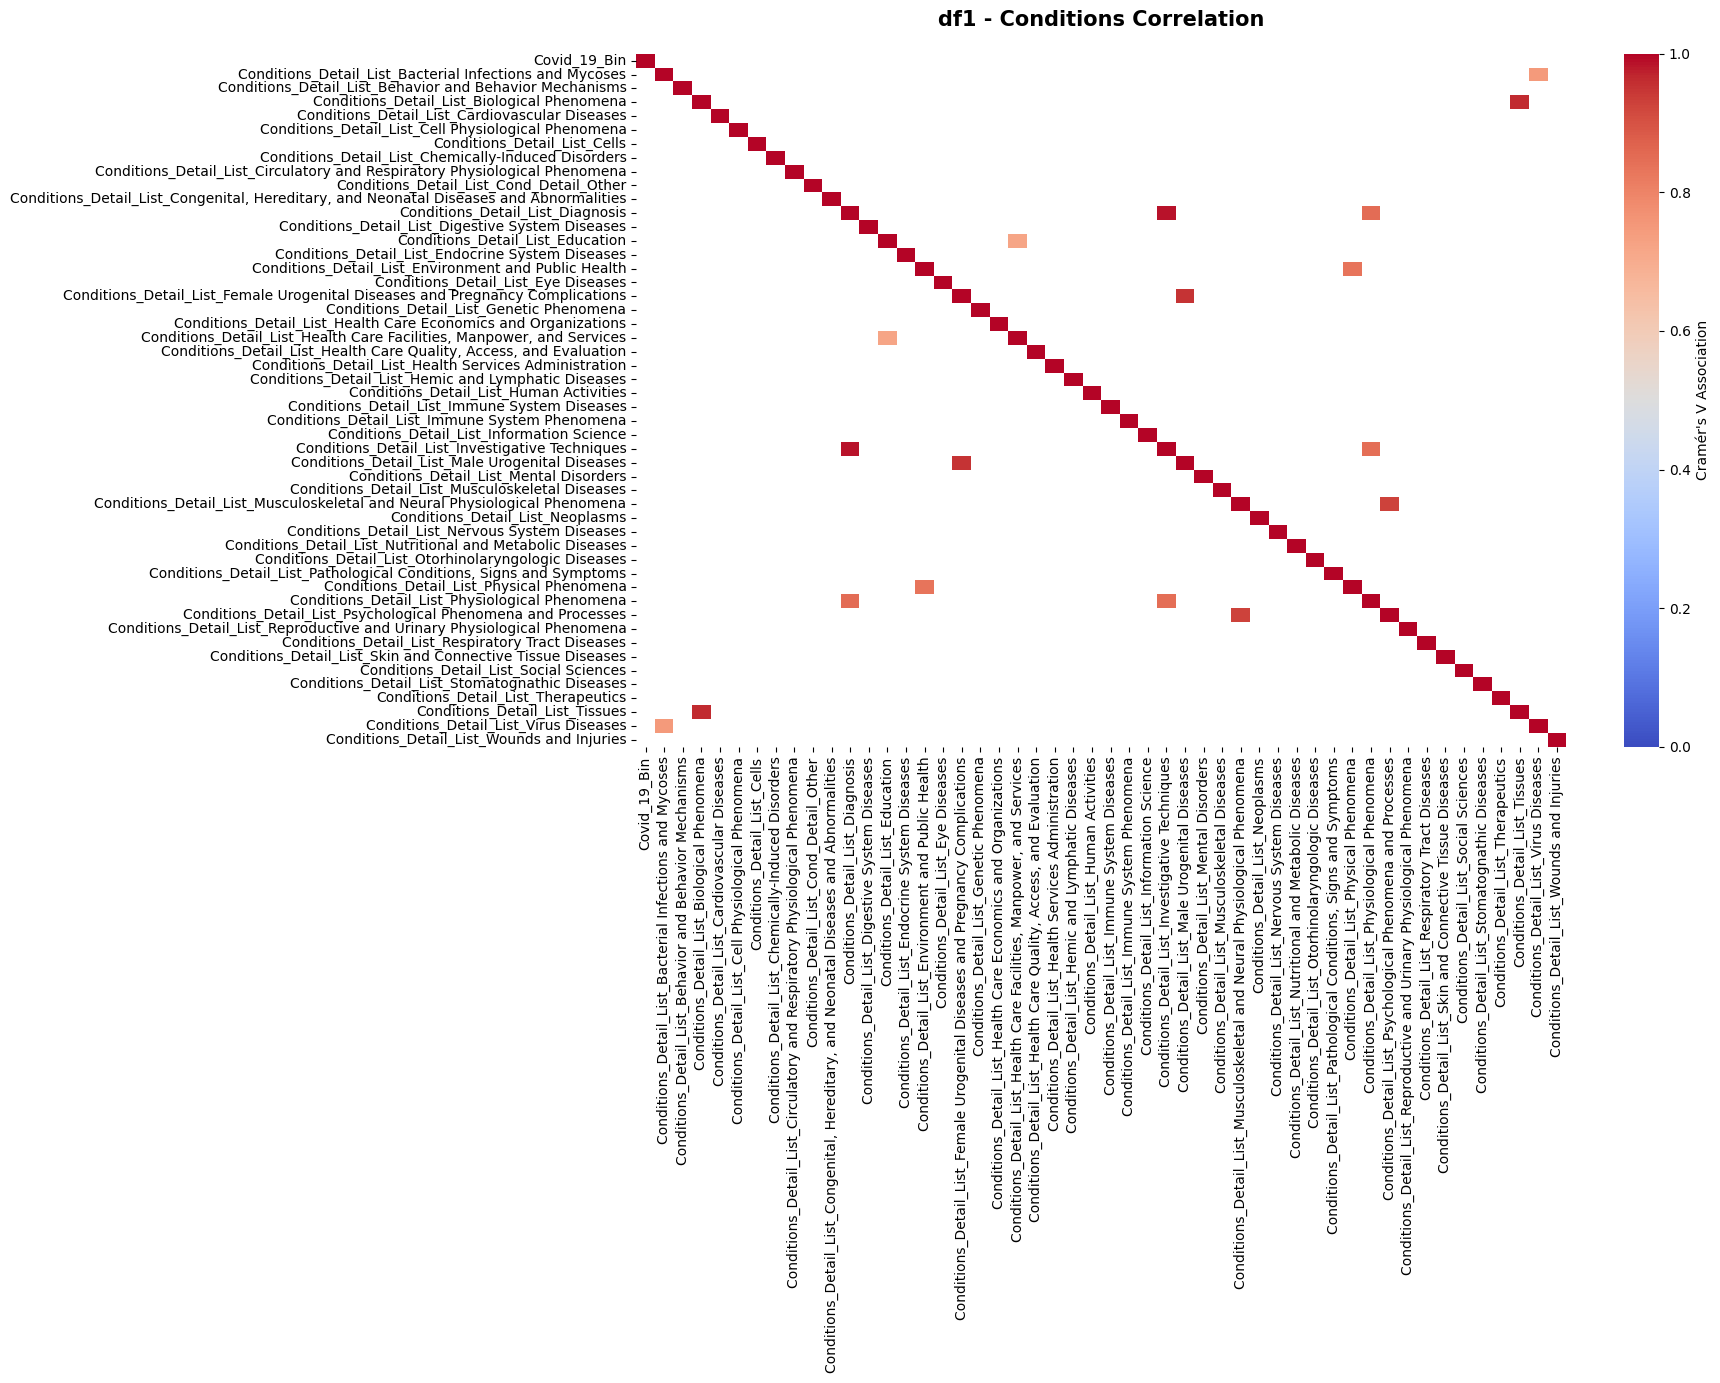

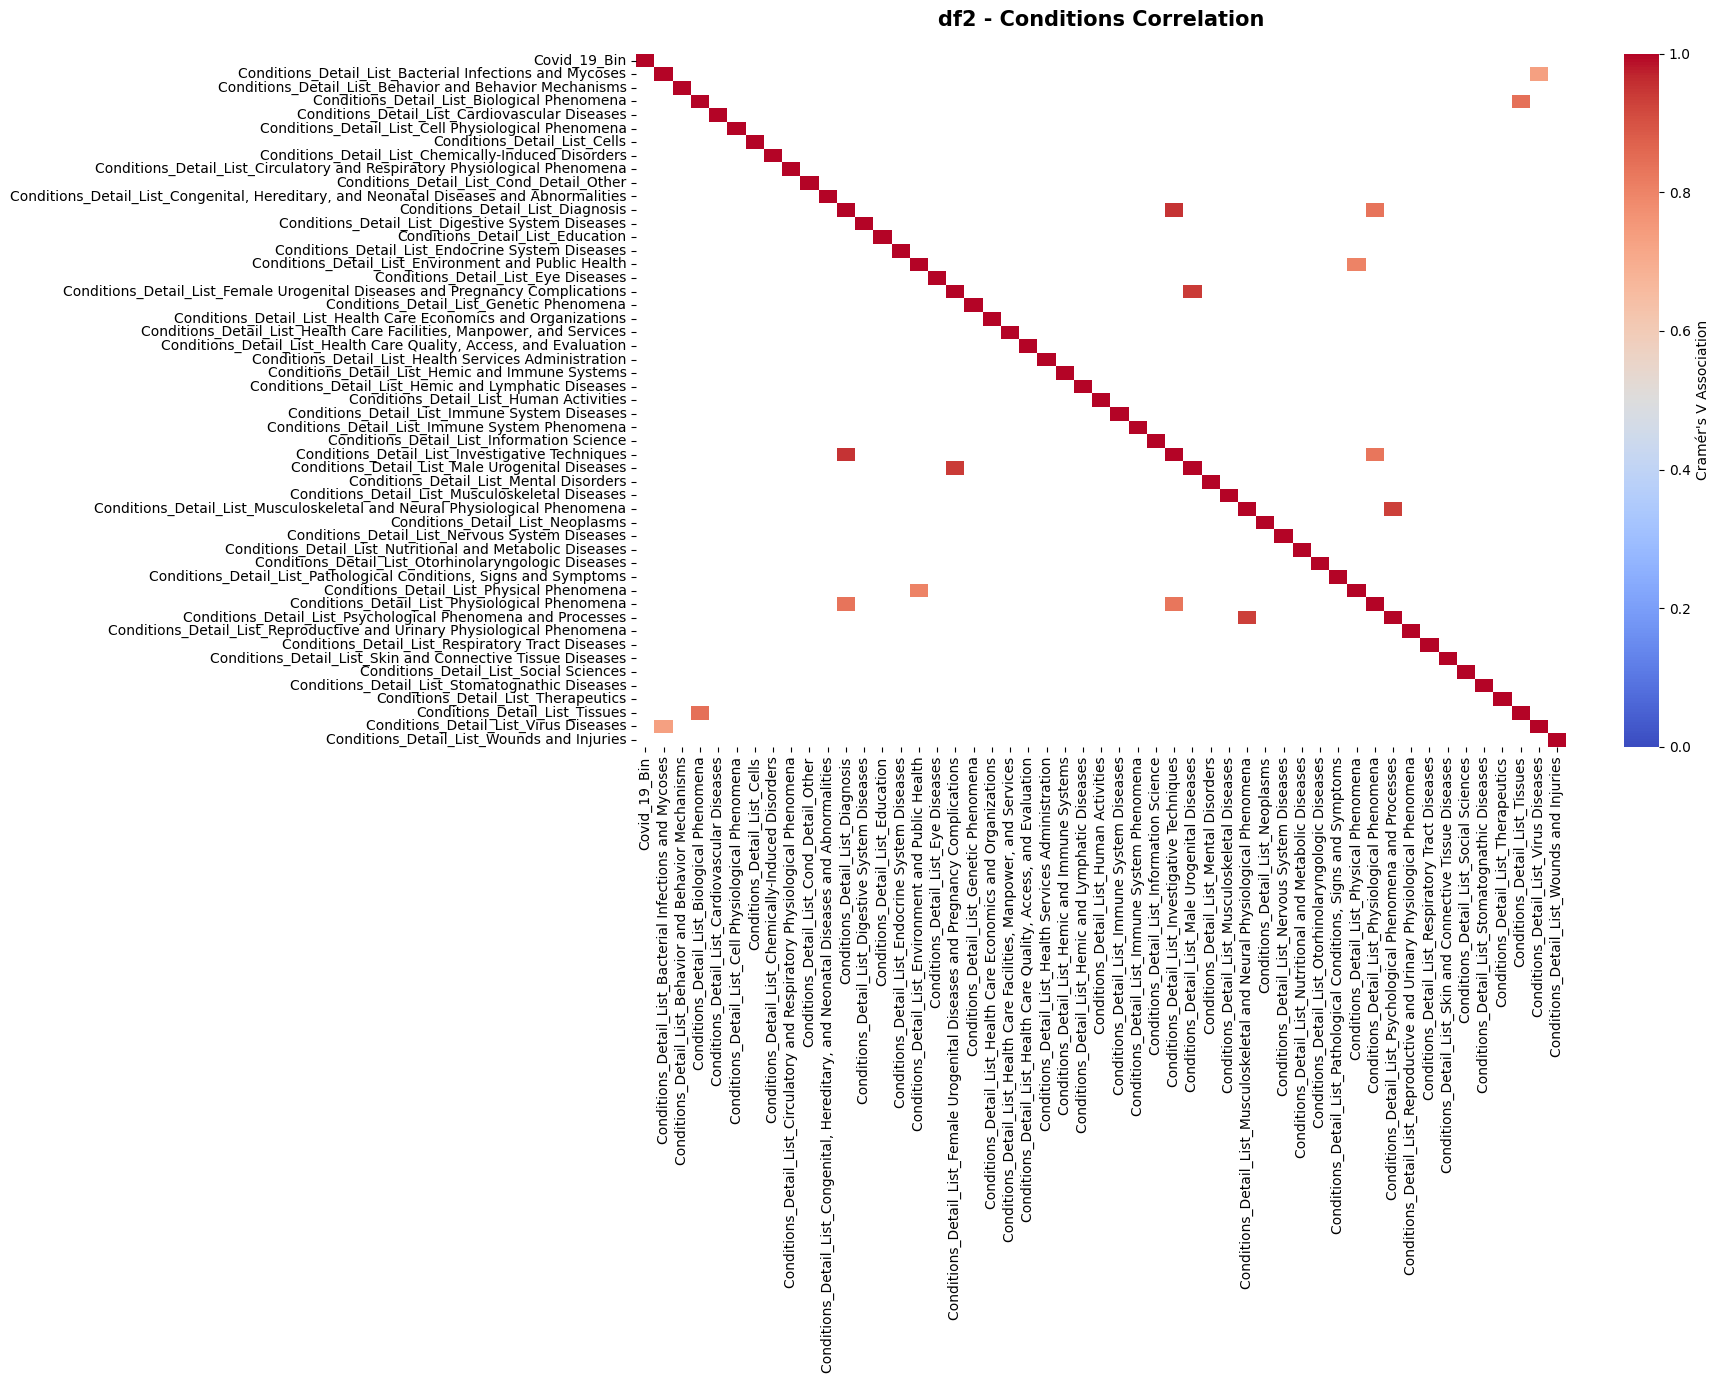

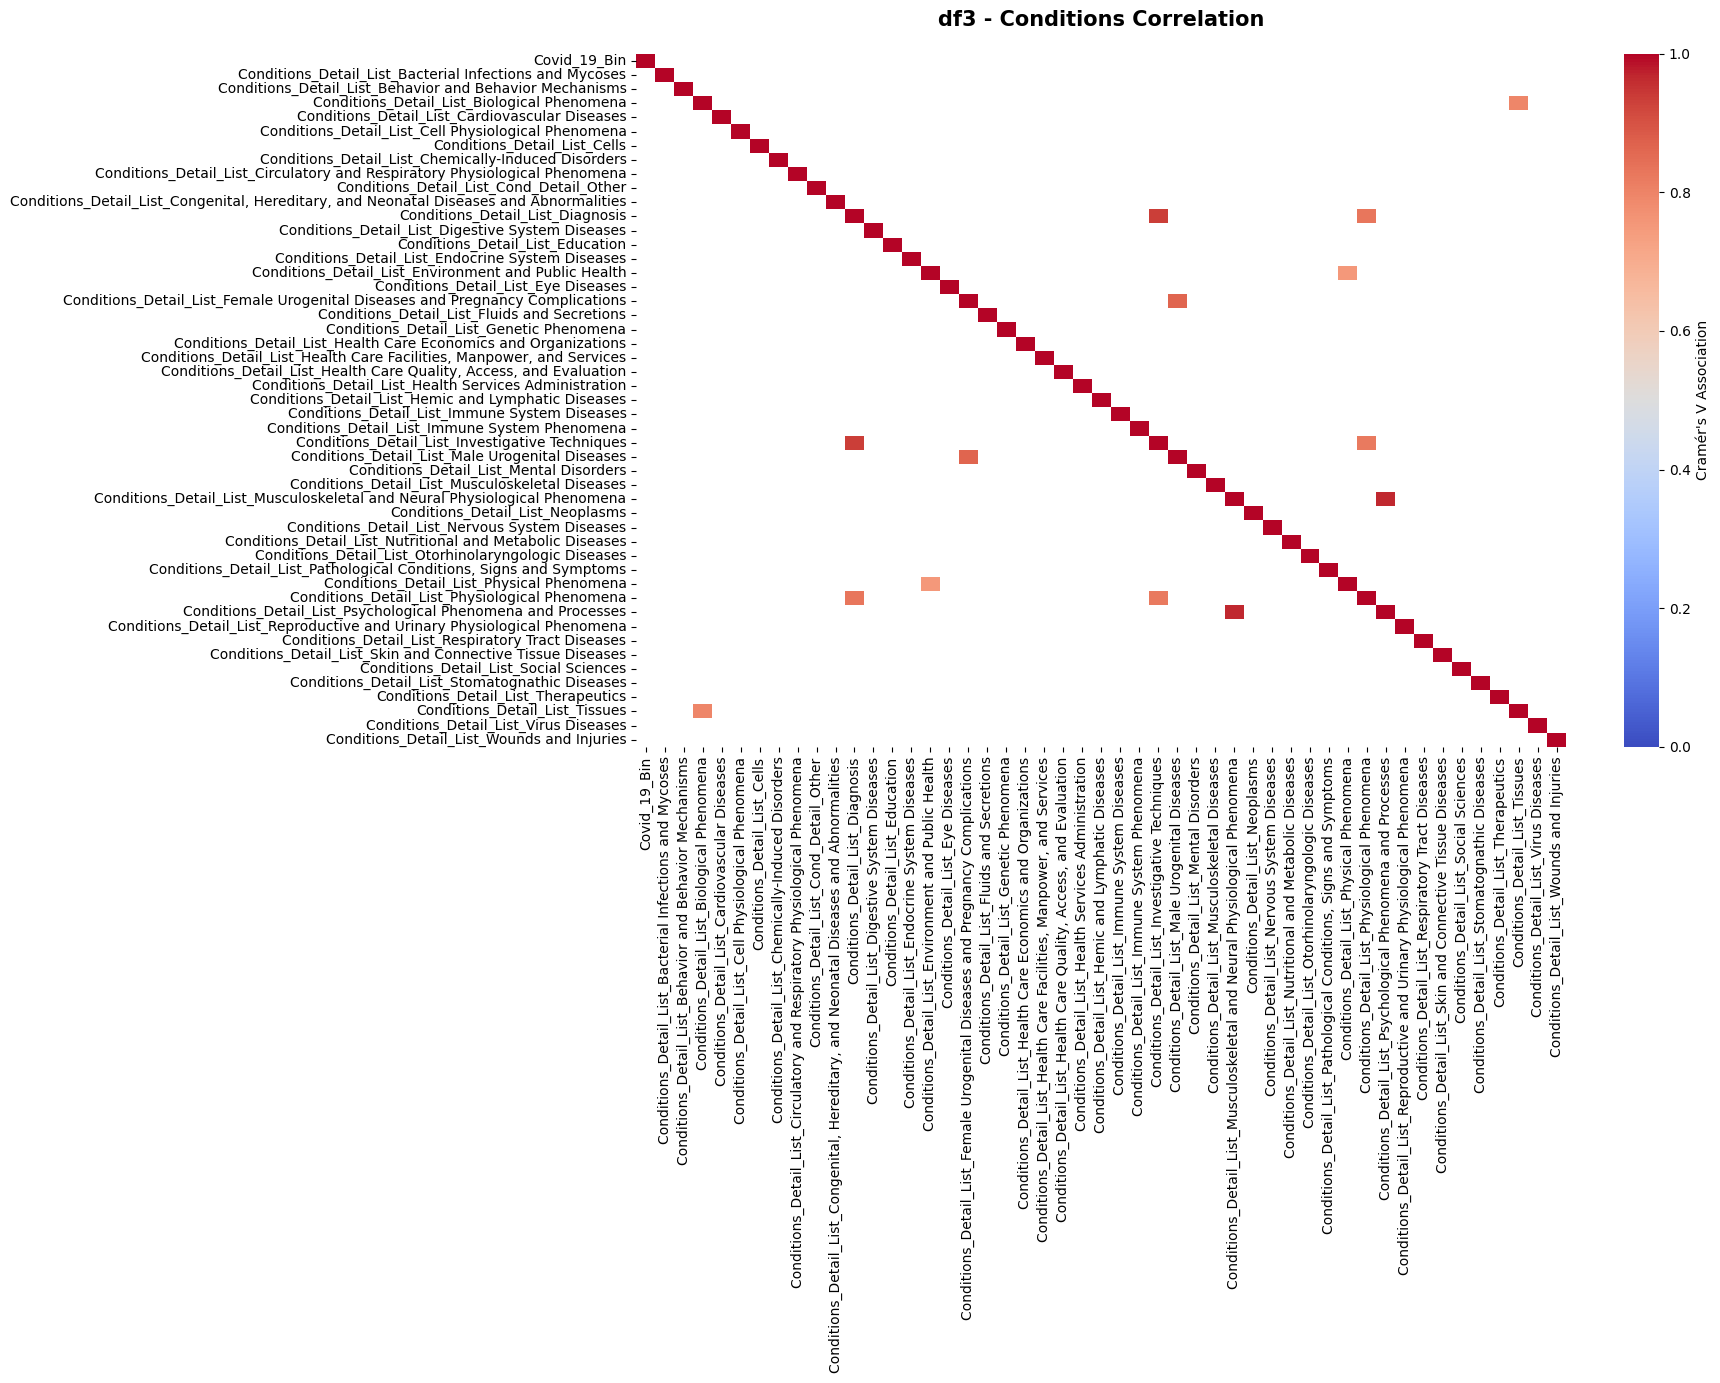

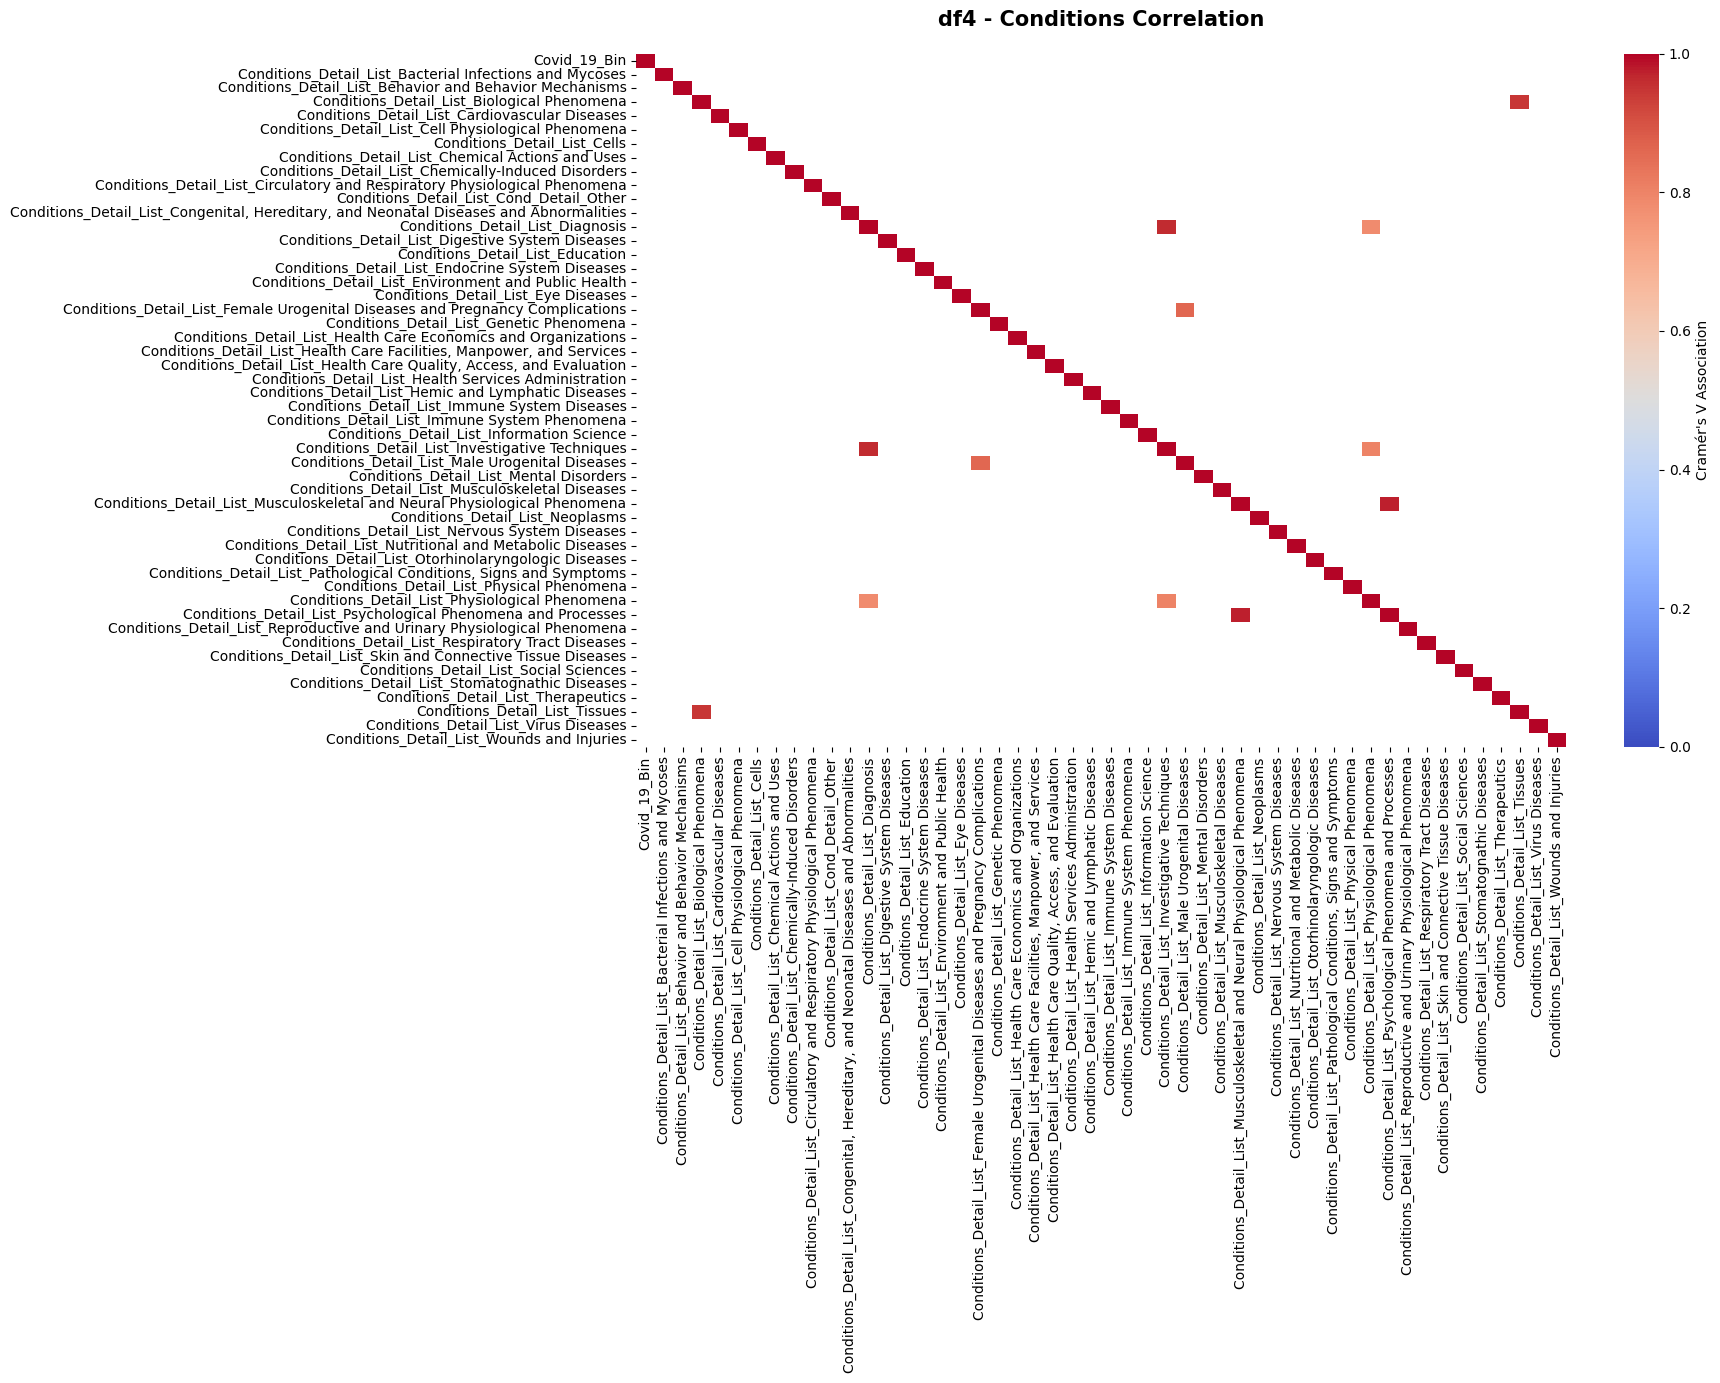

In [ ]:
figsize = (15, 9)
threshold = 0.7
fontsize = 10
title = f'Conditions Correlation'
show = True
rotation = 90

cond_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)
cond_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)
cond_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)
cond_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold, fontsize, title, show, rotation = rotation)

### Masking

In [ ]:
figsize = (10, 2)
threshold = 0.7
fontsize = 8
title = f'Masking Correlation'
show = False
rotation = 90
mask_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Masking' in col], figsize , True, threshold, fontsize, title, show, rotation = rotation)
mask_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Masking' in col], figsize , True, threshold, fontsize, title, show, rotation = rotation)
mask_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Masking' in col], figsize , True, threshold, fontsize, title, show, rotation = rotation)
mask_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Masking' in col], figsize , True, threshold, fontsize, title, show, rotation = rotation)

### Primary Purpose

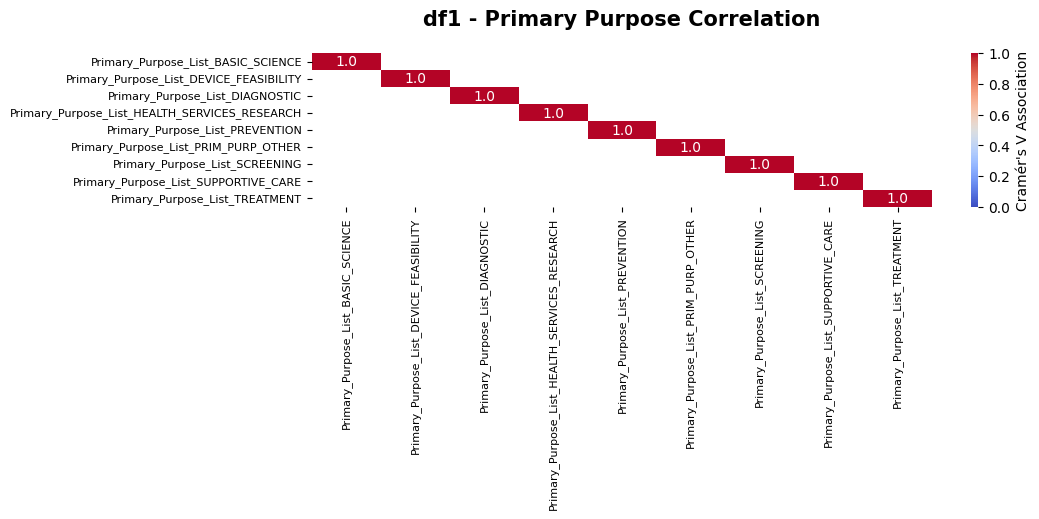

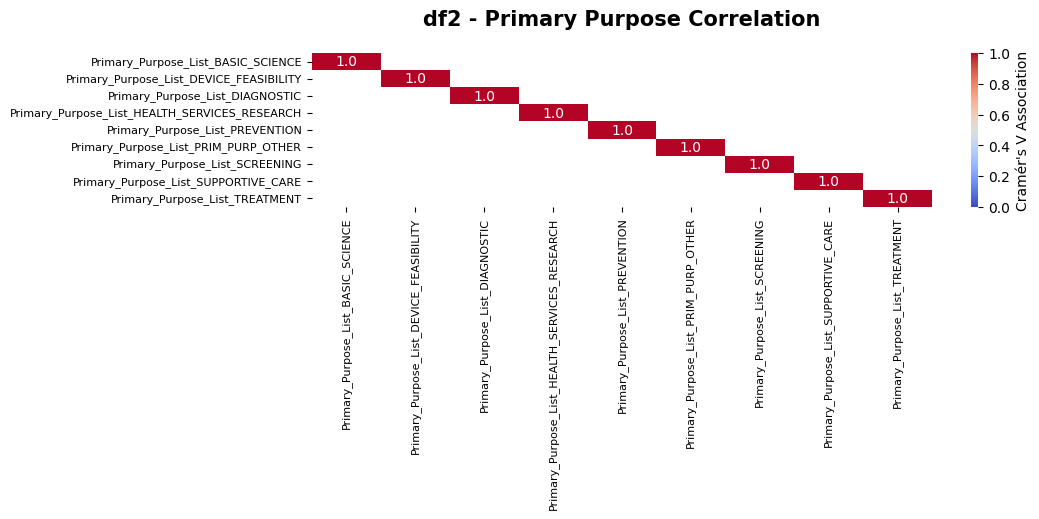

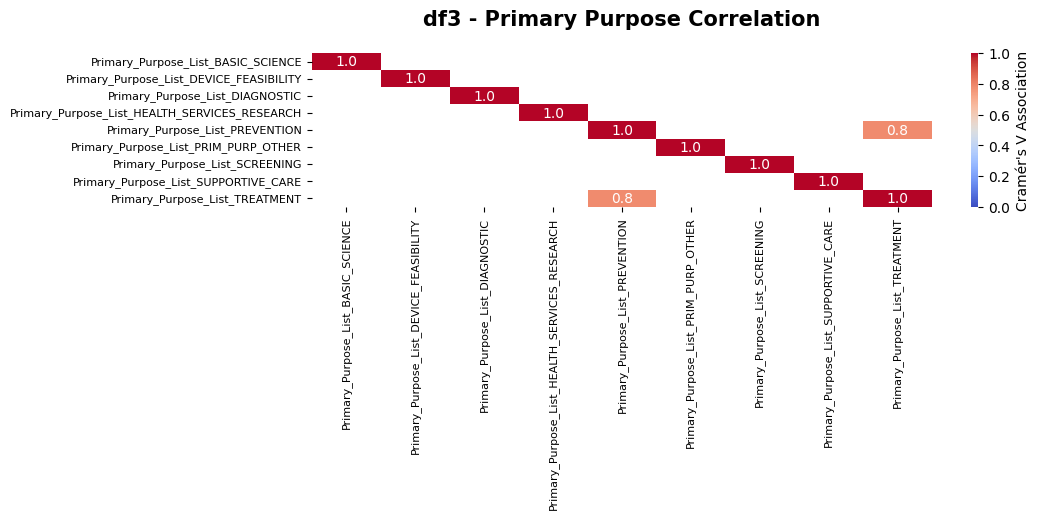

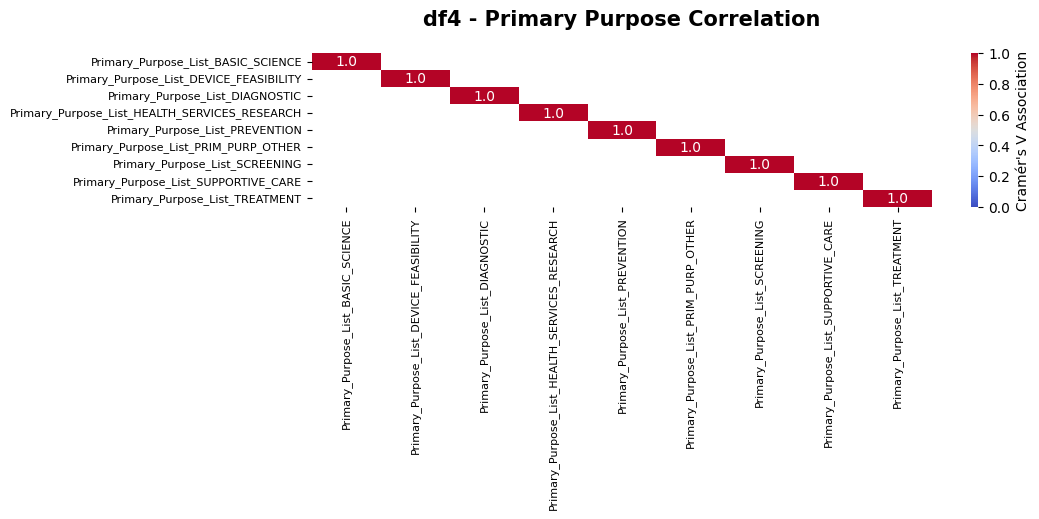

In [ ]:
figsize = (10, 2)
threshold = 0.7
fontsize = 8
title = f'Primary Purpose Correlation'
show = True
rotation = 90

purp_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Primary' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)
purp_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Primary' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)
purp_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Primary' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)
purp_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Primary' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)

### Intervention_Type

In [ ]:
figsize = (8, 3)
threshold = 0.7
fontsize = 10
title = f'Intervention Type Correlation'
show = False
rotation = 90

inter_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Intervention_Type' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)
inter_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Intervention_Type' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)
inter_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Intervention_Type' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)
inter_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Intervention_Type' in col],figsize , True, threshold, fontsize, title, show, rotation = rotation)

## Categ x Continues

In [ ]:
figsize = (50, 10)
threshold = 0.7
dfi = X_train4
i = 4
fontsize = 10
title = f'Categorical x Continues Correlation'
show = False
rotation = 90

categ_cont_corr1 = fun_anova(dfi, i, 
    categ_cols = [col for col in dfi.columns if '_Categ' in col or '_Bin' in col or '_List' in col], 
    cont_cols = [col for col in dfi.columns if '_Log' in col or '_Counts' in col], annot = False, 
    figsize = figsize, threshold = threshold, fontsize = fontsize, title = title, show = show, rotation = rotation)                  

### Adverse

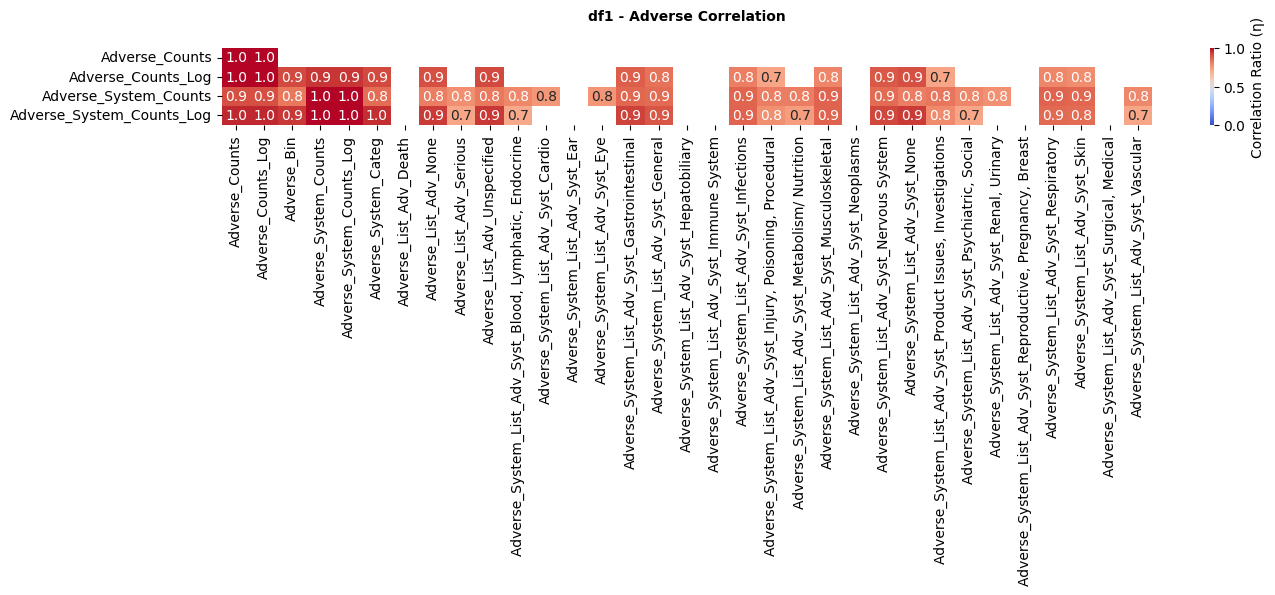

In [ ]:
figsize = (15, 1)
threshold = 0.7
fontsize = 10
title = f'Adverse Correlation'
show = True
rotation = 90

categ_cont_corr1 = fun_anova(X_train1, 1, 
    categ_cols = [col for col in X_train1.columns if 'Adverse' in col], 
    cont_cols = [col for col in X_train1.columns if 'Adverse' in col and '_Counts' in col], annot = True, figsize = figsize, 
    threshold = threshold, fontsize = fontsize, title=title, show = show, rotation = rotation)                  

# Models

## Adverse

In [17]:
X = X_train1[[col for col in X_train1.columns if 'Adverse_List' in col]]
aic_adv_list = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Adverse_List: {aic_adv_list}')

X = X_train1[[col for col in X_train1.columns if 'Adverse_System_List' in col]]
aic_adv_syst = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Adverse_System_List: {aic_adv_syst}')

X = X_train1[[col for col in X_train1.columns if 'Adverse_Counts_Log' in col]]
aic_adv_list = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Adverse_Counts_Log: {aic_adv_list}')

'AIC Adverse_List: 14432.0'

'AIC Adverse_System_List: 14389.0'

'AIC Adverse_Counts_Log: 14508.0'

## Masking

In [18]:
X = X_train1[[col for col in X_train1.columns if 'Masking_List' in col]]
aic_mask = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Masking_List: {aic_mask}')

X = X_train1[[col for col in X_train1.columns if 'Masking_Detail' in col]]
aic_mask_det = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Masking_Detail: {aic_mask_det}')

'AIC Masking_List: 14384.0'

'AIC Masking_Detail: 14386.0'

## Locations

In [19]:
X = X_train1['City_Counts_Log']
aic_cities = fun_aic(X, y_train1, 1, True, False)
display(f'AIC Cities_Counts_Log: {aic_cities}')

X = X_train1['Country_Counts_Log']
aic_countries = fun_aic(X, y_train1, 1, True, False)
display(f'AIC Countries_Counts_Log: {aic_countries}')

'AIC Cities_Counts_Log: 14430.0'

'AIC Countries_Counts_Log: 14510.0'

## Enrollment

In [20]:
X = X_train4_merge['Enrollment_Counts_Log']
aic_enroll = fun_aic(X, y_train4_merge, 1, True, True)
display(f'AIC Enrollment_Counts_Log: {aic_enroll}')

X = X_train4_merge[[col for col in X_train4_merge.columns if 'City_Counts_Log' in col]]  #??
aic_cenroll_city = fun_aic(X, y_train4_merge, 1, True, True)
display(f'AIC City_Counts_Log: {aic_cenroll_city}')

X = X_train4_merge[[col for col in X_train4_merge.columns if 'Enrollment_Log_x_City_Log' in col]]  #??
aic_cenroll_city = fun_aic(X, y_train4_merge, 1, True, True)
display(f'AIC Enrollment_x_City: {aic_cenroll_city}')

X = X_train4_merge[[col for col in X_train4_merge.columns if 'Enrollment_Log_x_City' in col or 'Enrollment_Counts_Log' in col or 'City_Counts_Log' in col]]
aic_cenroll_all = fun_aic(X, y_train4_merge, 1, True, True)
display(f'AIC Enrollment_x_City, All: {aic_cenroll_all}')

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                 9936
Model:                          Logit   Df Residuals:                     9934
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:                  0.2051
Time:                        22:26:49   Log-Likelihood:                -2887.9
converged:                       True   LL-Null:                       -3633.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.0238      0.114     17.725      0.000       1.800       2.248
Enrollment_Counts_Log    -1.0833      0.033    -33.089      0.000      -1.147      -1.019


'AIC Enrollment_Counts_Log: 5780.0'

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                 9936
Model:                          Logit   Df Residuals:                     9934
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:               0.0004233
Time:                        22:26:49   Log-Likelihood:                -3631.6
converged:                       True   LL-Null:                       -3633.2
Covariance Type:            nonrobust   LLR p-value:                   0.07946
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.9262      0.052    -37.312      0.000      -2.027      -1.825
City_Counts_Log    -0.0650      0.038     -1.722      0.085      -0.139       0.009


'AIC City_Counts_Log: 7267.0'

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                 9936
Model:                          Logit   Df Residuals:                     9934
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:                 0.02600
Time:                        22:26:49   Log-Likelihood:                -3538.7
converged:                       True   LL-Null:                       -3633.2
Covariance Type:            nonrobust   LLR p-value:                 5.515e-43
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.4580      0.053    -27.624      0.000      -1.561      -1.355
Enrollment_Log_x_City_Log    -0.1279      0.012    -10.854      0.000      -0.151     

'AIC Enrollment_x_City: 7081.0'

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                 9936
Model:                          Logit   Df Residuals:                     9932
Method:                           MLE   Df Model:                            3
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:                  0.2151
Time:                        22:26:49   Log-Likelihood:                -2851.5
converged:                       True   LL-Null:                       -3633.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         2.3201      0.182     12.724      0.000       1.963       2.677
City_Counts_Log              -0.0905      0.130     -0.695      0.487      -0.346     

'AIC Enrollment_x_City, All: 5711.0'

## Funder

In [22]:
X = X_train4_merge['DRUG_x_Funder_Industry_Bin']
aic_enroll = fun_aic(X, y_train4_merge, 1, True, True)
display(f'AIC DRUG_x_Funder_Industry_Bin: {aic_enroll}')

X = X_train4_merge[['Funder_Industry_Bin']]  #??
aic_cenroll_city = fun_aic(X, y_train4_merge, 1, True, True)
display(f'AIC Funder_Industry_Bin: {aic_cenroll_city}')

X = X_train4_merge[[col for col in X_train4_merge.columns if 'Funder_Industry_Bin' in col]]  #??
aic_cenroll_city = fun_aic(X, y_train4_merge, 1, True, True)
display(f'AIC Fundr all: {aic_cenroll_city}')


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                 9936
Model:                          Logit   Df Residuals:                     9934
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:               0.0001572
Time:                        22:27:21   Log-Likelihood:                -3632.6
converged:                       True   LL-Null:                       -3633.2
Covariance Type:            nonrobust   LLR p-value:                    0.2852
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -1.9855      0.033    -59.835      0.000      -2.051      -1.920
DRUG_x_Funder_Industry_Bin    -0.0965      0.092     -1.049      0.294      -0.277 

'AIC DRUG_x_Funder_Industry_Bin: 7269.0'

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                 9936
Model:                          Logit   Df Residuals:                     9934
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:               0.0004563
Time:                        22:27:21   Log-Likelihood:                -3631.5
converged:                       True   LL-Null:                       -3633.2
Covariance Type:            nonrobust   LLR p-value:                   0.06863
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.9718      0.034    -57.920      0.000      -2.039      -1.905
Funder_Industry_Bin    -0.1468      0.082     -1.796      0.072      -0.307       0.013


'AIC Funder_Industry_Bin: 7267.0'

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                 9936
Model:                          Logit   Df Residuals:                     9933
Method:                           MLE   Df Model:                            2
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:               0.0005476
Time:                        22:27:21   Log-Likelihood:                -3631.2
converged:                       True   LL-Null:                       -3633.2
Covariance Type:            nonrobust   LLR p-value:                    0.1368
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -1.9717      0.034    -57.919      0.000      -2.038      -1.905
Funder_Industry_Bin           -0.2501      0.153     -1.637      0.102      -0.549 

'AIC Fundr all: 7268.0'